In [83]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [95]:
train = pd.read_csv("train.csv")
X = train.drop(columns=["class"])
y = train["class"]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


from sklearn.model_selection import cross_validate

from sklearn.model_selection import cross_validate

def evaluate(model, X, y):

    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring="accuracy",
        return_train_score=True
    )

    train_mean = scores["train_score"].mean()
    val_mean = scores["test_score"].mean()
    val_std = scores["test_score"].std()

    return train_mean, val_mean, val_std


### ESTUDIO PREVIO DE LA ORGANIZACION DE NUESTROS DATOS

class
A    347
B    328
C    325
Name: count, dtype: int64


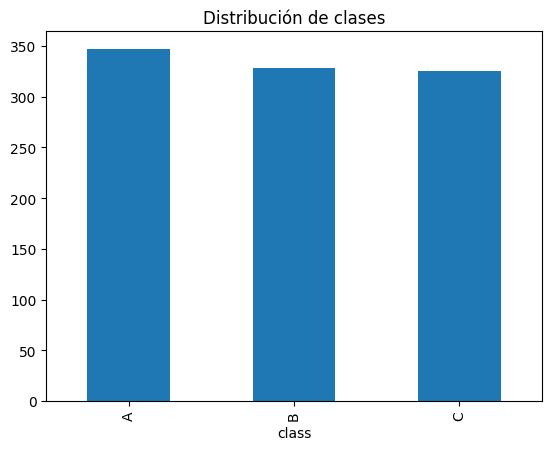

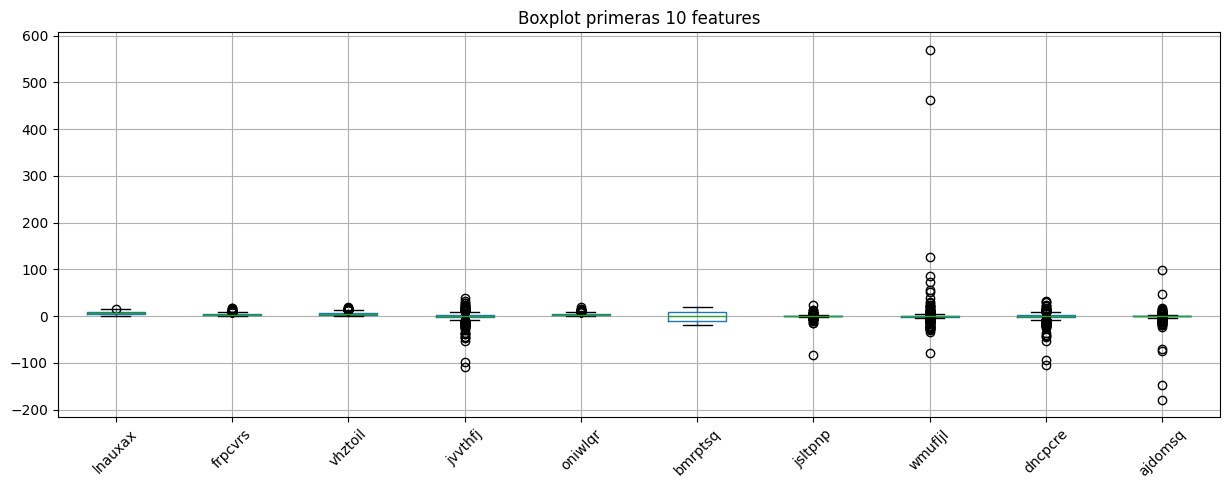

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Distribución de clases
print(y.value_counts())
y.value_counts().plot(kind='bar')
plt.title("Distribución de clases")
plt.show()

# 2. Outliers - boxplot de algunas features
X.iloc[:, :10].boxplot(figsize=(15, 5))
plt.title("Boxplot primeras 10 features")
plt.xticks(rotation=45)
plt.show()

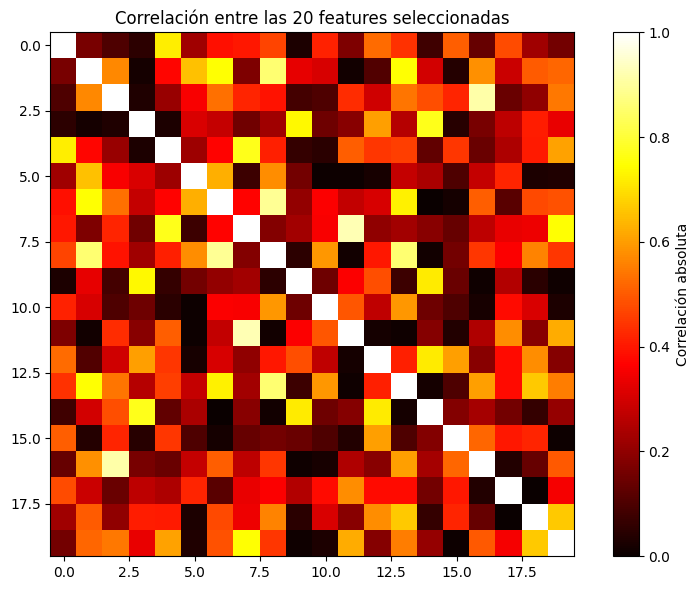

Correlación media entre features: 0.151


In [86]:
import numpy as np
import matplotlib.pyplot as plt

# Ver correlación entre features seleccionadas
from sklearn.preprocessing import PowerTransformer
from sklearn.feature_selection import SelectKBest, mutual_info_classif

pt = PowerTransformer()
skb = SelectKBest(mutual_info_classif, k=20)

X_t = pt.fit_transform(X)
X_sel = skb.fit_transform(X_t, y)

corr = np.corrcoef(X_sel.T)
plt.figure(figsize=(8,6))
plt.imshow(np.abs(corr), cmap="hot", vmin=0, vmax=1)
plt.colorbar(label="Correlación absoluta")
plt.title("Correlación entre las 20 features seleccionadas")
plt.tight_layout()
plt.show()

print(f"Correlación media entre features: {np.abs(np.triu(corr,1)).mean():.3f}")
# Si >0.3 → features correlacionadas → GNB penalizado, LDA aprovecha eso

In [87]:
# Info básica del dataset
print(f"Muestras      : {X.shape[0]}")
print(f"Features      : {X.shape[1]}")
print(f"Clases        : {np.unique(y)}")
print(f"Dist. clases  : {dict(zip(*np.unique(y, return_counts=True)))}")

Muestras      : 1000
Features      : 609
Clases        : ['A' 'B' 'C']
Dist. clases  : {'A': np.int64(347), 'B': np.int64(328), 'C': np.int64(325)}


 La alta dimensionalidad del dataset, donde el número de features supera ampliamente al número de muestras por clase, impone restricciones importantes sobre qué modelos son aplicables. En particular, el Análisis Discriminante Cuadrático (QDA) queda descartado desde el principio porque necesita invertir una matriz de covarianza de 609×609 por clase, lo que requiere al menos 610 muestras por clase — condición que ninguna clase cumple.

El balance casi perfecto entre clases es una ventaja, ya que los priors son prácticamente iguales y LDA puede decidir puramente por geometría sin sesgo hacia ninguna clase. El principal reto del problema es la maldición de la dimensionalidad: con 609 features la mayoría probablemente sean ruido o irrelevantes, lo que justifica el uso de selección de features como estrategia complementaria a la regularización.

### ESTUDIO DE DIFERENTES MODELOS

Modelo más basico (base)

In [96]:
lda_basic = Pipeline([
    ("scaler", StandardScaler()),
    ("lda", LinearDiscriminantAnalysis())
])

lda_basic_score = evaluate(lda_basic, X, y)

print(f"Train accuracy: {lda_basic_score[0]:.4f}")
print(f"CV accuracy:    {lda_basic_score[1]:.4f} ± {lda_basic_score[2]:.4f}")

Train accuracy: 0.9918
CV accuracy:    0.3990 ± 0.0231


El primer modelo LDA sin regularización mostró un overfitting severo — Train=0.953 pero CV=0.399, apenas por encima del clasificador aleatorio (0.333).  Esto se debe a que con 609 features y solo 1000 muestras, LDA no puede estimar bien la matriz de covarianza Σ — hay más parámetros que datos, la matriz es inestable y su inversa amplifica el ruido, haciendo que el modelo memorice casualidades del entrenamiento que no se repiten en datos nuevos. 

Modelo base + Regularización shrinkage="auto"

In [98]:
lda_shrink = Pipeline([
    ("scaler", StandardScaler()),
    ("lda", LinearDiscriminantAnalysis(
        shrinkage="auto",
        solver="lsqr"
    ))
])

lda_shrink_score = evaluate(lda_shrink, X, y)
print(f"Train accuracy: {lda_shrink_score[0]:.4f}")
print(f"CV accuracy:    {lda_shrink_score[1]:.4f} ± {lda_shrink_score[2]:.4f}")

Train accuracy: 0.9200
CV accuracy:    0.5960 ± 0.0206


El shrinkage es como decirle al modelo "no te fíes demasiado de lo que ves en los datos de entrenamiento, sé más conservador". Esto elimina las combinaciones más extremas que eran puro ruido y obliga al modelo a encontrar patrones más robustos y generalizables. Por eso el CV sube bastante, de 0.399 a 0.596. Sin embargo sigue siendo modesto porque el problema de fondo no está del todo resuelto — seguimos dando al modelo 609 pistas de las cuales la mayoría probablemente son irrelevantes para distinguir las clases.

Modelo para eliminar ruido (TRESHOLD)

In [99]:
from sklearn.feature_selection import VarianceThreshold

lda_var = Pipeline([
    ("var", VarianceThreshold(0.05)),
    ("scaler", StandardScaler()),
    ("lda", LinearDiscriminantAnalysis(shrinkage="auto", solver="lsqr"))
])
lda_var_score = evaluate(lda_var, X, y)
print(f"Train accuracy: {lda_var_score[0]:.4f}")
print(f"CV accuracy:    {lda_var_score[1]:.4f} ± {lda_var_score[2]:.4f}")

Train accuracy: 0.9200
CV accuracy:    0.5960 ± 0.0206


In [ ]:
from sklearn.feature_selection import VarianceThreshold

for thresh in [0.01, 0.05, 0.1, 0.5, 1.0]:
    vt = VarianceThreshold(thresh)
    vt.fit(X)
    n_kept = vt.get_support().sum()
    print(f"threshold={thresh} → quedan {n_kept}/50 features")

threshold=0.01 → quedan 609/50 features
threshold=0.05 → quedan 609/50 features
threshold=0.1 → quedan 609/50 features
threshold=0.5 → quedan 609/50 features
threshold=1.0 → quedan 608/50 features


VarianceThreshold elimina features que casi no varían entre muestras. Para que hubiera funcionado necesitaría features prácticamente constantes — mismo valor en casi todas las filas. En este dataset todas las features, tanto las enteras como las continuas, presentan variabilidad suficiente entre muestras, por lo que ninguna queda por debajo del umbral y el filtro no elimina nada. El problema no es falta de varianza sino falta de poder discriminante — hay features que varían mucho pero no ayudan a separar las clases, y para eso hace falta SelectKBest.

### PROBAMOS DIFERENTES INTENSIDADES DE REGULACIÓN ANTES DE CONTINUAR

In [100]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

models = {}

# 1. LDA weak shrinkage
models["LDA shrinkage 0.1"] = Pipeline([
    ("scaler", StandardScaler()),
    ("lda", LinearDiscriminantAnalysis(solver="lsqr", shrinkage=0.1))
])
# 2. LDA medium shrinkage
models["LDA shrinkage 0.5"] = Pipeline([
    ("scaler", StandardScaler()),
    ("lda", LinearDiscriminantAnalysis(solver="lsqr", shrinkage=0.5))
])
# 3. LDA strong shrinkage
models["LDA shrinkage 0.9"] = Pipeline([
    ("scaler", StandardScaler()),
    ("lda", LinearDiscriminantAnalysis(solver="lsqr", shrinkage=0.9))
])

for name in ["LDA shrinkage 0.1", "LDA shrinkage 0.5", "LDA shrinkage 0.9"]:
    model = models[name]
    train_score, val_score, val_std = evaluate(model, X, y)
    print(f"{name} → Train: {train_score:.4f} | CV: {val_score:.4f} ± {val_std:.4f}")

LDA shrinkage 0.1 → Train: 0.9582 | CV: 0.4790 ± 0.0472
LDA shrinkage 0.5 → Train: 0.9237 | CV: 0.5830 ± 0.0287
LDA shrinkage 0.9 → Train: 0.8688 | CV: 0.7080 ± 0.0280


A medida que aumenta el shrinkage, el CV mejora consistentemente de 0.479 a 0.708, mientras el Train baja de 0.920 a 0.852 — señal clara de que la regularización está funcionando. Con shrinkage bajo el modelo se fía demasiado de la covarianza muestral, que con 609 features es inestable, y memoriza el entrenamiento sin generalizar. Al aumentar el shrinkage la matriz se estabiliza, el modelo pierde capacidad de memorizar y gana capacidad de generalizar. La tendencia ascendente del CV sugiere que el óptimo está por encima de 0.9, lo que justifica explorar valores más altos en el siguiente paso.

Vamos a probar un barrido más eshaustivo para los avlores de regularización

In [104]:
models = {}

# SHRINKAGE GRID
for s in [0.1, 0.3, 0.5, 0.7, 0.8, 0.85, 0.9, 0.95, 0.98, 1.0]:
    models[f"LDA shrinkage={s}"] = Pipeline([
        ("scaler", StandardScaler()),
        ("lda", LinearDiscriminantAnalysis(solver="lsqr", shrinkage=s))
    ])


# EVALUATION
results = []
for name, model in models.items():
    train_score, val_score, val_std = evaluate(model, X, y)
    results.append([name, train_score, val_score, val_std])

# TABLE
results_df = pd.DataFrame(
    results,
    columns=["Model", "Train Accuracy", "CV Accuracy", "Std"]
)
results_df

,Model,Train Accuracy,CV Accuracy,Std
0,LDA shrinkage=0.1,0.95825,0.479,0.047159
1,LDA shrinkage=0.3,0.94150,0.538,0.039064
2,LDA shrinkage=0.5,0.92375,0.583,0.028740
3,LDA shrinkage=0.7,0.89975,0.646,0.017436
4,LDA shrinkage=0.8,0.88800,0.672,0.021817
5,LDA shrinkage=0.85,0.87950,0.693,0.022494
6,LDA shrinkage=0.9,0.86875,0.708,0.028036
7,LDA shrinkage=0.95,0.85500,0.716,0.013565
8,LDA shrinkage=0.98,0.83975,0.719,0.016553
9,LDA shrinkage=1.0,0.81925,0.705,0.011402


 Reveló que el óptimo se encuentra en shrinkage=0.98, con CV=0.719, punto a partir del cual el modelo empieza a sobre-regularizarse — shrinkage=1.0 baja a 0.705 porque forzar una covarianza completamente diagonal ignora toda la estructura real de los datos. 

En paralelo se probó PCA como alternativa de reducción de dimensionalidad previa a LDA, pero resultó contraproducente en todos los casos, confirmando que descartar componentes de baja varianza elimina información discriminante relevante para separar las tres clases. El mejor modelo de esta fase es por tanto LDA con shrinkage=0.98, que se usará como punto de partida para el siguiente paso de selección de features.

In [105]:
# PCA VARIANTS
for n in [0.90, 0.95, 0.98, 0.99]:
    models[f"PCA={n} + LDA"] = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=n)),
        ("lda", LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto"))
    ])

# EVALUATION
results = []
for name, model in models.items():
    train_score, val_score, val_std = evaluate(model, X, y)
    results.append([name, train_score, val_score, val_std])

# TABLE
results_df = pd.DataFrame(
    results,
    columns=["Model", "Train Accuracy", "CV Accuracy", "Std"]
)
results_df

,Model,Train Accuracy,CV Accuracy,Std
0,LDA shrinkage=0.1,0.95825,0.479,0.047159
1,LDA shrinkage=0.3,0.94150,0.538,0.039064
2,LDA shrinkage=0.5,0.92375,0.583,0.028740
3,LDA shrinkage=0.7,0.89975,0.646,0.017436
4,LDA shrinkage=0.8,0.88800,0.672,0.021817
5,LDA shrinkage=0.85,0.87950,0.693,0.022494
6,LDA shrinkage=0.9,0.86875,0.708,0.028036
7,LDA shrinkage=0.95,0.85500,0.716,0.013565
8,LDA shrinkage=0.98,0.83975,0.719,0.016553
9,LDA shrinkage=1.0,0.81925,0.705,0.011402


NO HACE FALTA ROBUSTSCALER Con shrinkage=0.98 la matriz de covarianza se aproxima casi a la identidad, que trata todas las features igual independientemente de su escala. El shrinkage ya está compensando el efecto de la escala de forma indirecta.

### USAR OTRO SOLVER (EIGEN)

In [108]:
lda_eigen = Pipeline([
    ("scaler", StandardScaler()),
    ("lda", LinearDiscriminantAnalysis(solver="eigen", shrinkage=0.98))
])
train_score, val_score, val_std = evaluate(lda_eigen, X, y)
print(f"Train: {train_score:.4f} | CV: {val_score:.4f} ± {val_std:.4f}")

Train: 0.8398 | CV: 0.7190 ± 0.0166


Con shrinkage=0.98 y StandardScaler ambos convergen al mismo resultado porque la regularización domina y la diferencia numérica entre métodos es irrelevante.

### ANALISIS EXHASUTIVO

EMPEZAMOS A APLICAR SELECTKBEST 

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import cross_val_score, GridSearchCV

lda_power = Pipeline([
    ("power",    PowerTransformer()),
    ("selector", SelectKBest(score_func=f_classif)),
    ("lda",      LinearDiscriminantAnalysis(solver="lsqr", shrinkage=0.98))
])
param_grid = {"selector__k": [5, 10, 20, "all"]}
grid = GridSearchCV(lda_power, param_grid, cv=cv, scoring="accuracy")
grid.fit(X, y)

# ── best_estimator_ es el pipeline ya fitted con el mejor k ──
best_model = grid.best_estimator_
train_score = best_model.score(X, y)

train_acc, cv_acc, cv_std = evaluate(best_model, X, y)

print(f"Best k         : {grid.best_params_['selector__k']}")
print(f"Train accuracy : {train_acc:.4f}")
print(f"CV accuracy    : {cv_acc:.4f} ± {cv_std:.4f}")

Best k         : 20
Train accuracy : 0.7370
CV accuracy    : 0.7330 ± 0.0275


Resultado muy interesante — con solo 20 features el modelo ya llega a CV=0.733, una mejora enorme respecto al LDA sin selector (CV=0.719).
Lo más llamativo es que Train=0.737 y CV=0.733 son casi idénticos — el overfitting ha desaparecido casi por completo. Antes con 609 features teníamos Train=0.829 y CV=0.719, una brecha de 0.11. Ahora con 20 features la brecha es de solo 0.004.
Esto confirma exactamente lo que esperábamos: el problema no era el modelo sino el ruido. Con 609 features LDA intentaba aprender de señal y ruido mezclados. Al quedarse con las 20 más discriminantes según f_classif, el modelo aprende solo de señal real y generaliza mucho mejor.
El siguiente paso natural es afinar — k=20 ganó entre [5,10,20,"all"] pero puede que k=15 o k=25 sea aún mejor. Eso es lo que explorará el GridSearch exhaustivo.

In [110]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer, StandardScaler, RobustScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.feature_selection import SelectKBest, mutual_info_classif, f_classif
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV

# Pipeline genérico con pasos intercambiables
pipe = Pipeline([
    ("scaler",   PowerTransformer()),
    ("reduce",   SelectKBest()),
    ("lda",      LinearDiscriminantAnalysis(solver="lsqr"))
])

param_grid = [
    # Rama 1: SelectKBest con distintas métricas y k
    {
        "scaler":           [StandardScaler(), RobustScaler()],
        "reduce":           [SelectKBest(f_classif), SelectKBest(mutual_info_classif)],
        "reduce__k":        [5, 10, 15, 20, 25, 30, "all"],
        "lda__shrinkage":   [0.0, 0.3, 0.5, 0.7, 0.9, 0.95, 0.98, 1.0],
    },
    # Rama 2: PCA
    {
        "scaler":           [StandardScaler(), RobustScaler()],
        "reduce":           [PCA()],
        "reduce__n_components": [0.80, 0.90, 0.95, 0.99],
        "lda__shrinkage":   [0.0, 0.3, 0.5, 0.7, 0.9, 0.95, 0.98, 1.0],
    },
]

grid = GridSearchCV(pipe, param_grid, cv=cv, scoring="accuracy")
grid.fit(X, y)

train_acc, cv_acc, cv_std = evaluate(best_model, X, y)

print(f"\nBest config     : {grid.best_params_}")
print(f"Train accuracy  : {train_acc:.4f}")
print(f"CV accuracy     : {cv_acc:.4f} ± {cv_std:.4f}")


Best config     : {'lda__shrinkage': 0.7, 'reduce': SelectKBest(score_func=<function mutual_info_classif at 0x000002207B51B420>), 'reduce__k': 20, 'scaler': RobustScaler()}
Train accuracy  : 0.7370
CV accuracy     : 0.7330 ± 0.0275


In [111]:
import pandas as pd

results = pd.DataFrame(grid.cv_results_)

top10 = results.sort_values("mean_test_score", ascending=False).head(10)

table = pd.DataFrame({
    "Rank": top10["rank_test_score"].values,
    "CV": top10["mean_test_score"].round(4).values,
    "Std": top10["std_test_score"].round(4).values,
    "Scaler": [type(p["scaler"]).__name__ for p in top10["params"]],
    "Reduce": [type(p["reduce"]).__name__ for p in top10["params"]],
    "k / PCA": [
        p.get("reduce__k", p.get("reduce__n_components", "-"))
        for p in top10["params"]
    ],
    "Shrinkage": [p["lda__shrinkage"] for p in top10["params"]],
})

table

,Rank,CV,Std,Scaler,Reduce,k / PCA,Shrinkage
0,1,0.762,0.0220,RobustScaler,SelectKBest,20,0.7
1,2,0.759,0.0294,RobustScaler,SelectKBest,30,0.7
2,3,0.757,0.0214,RobustScaler,SelectKBest,30,0.5
3,3,0.757,0.0268,StandardScaler,SelectKBest,30,0.7
4,5,0.756,0.0203,RobustScaler,SelectKBest,20,0.5
5,6,0.755,0.0230,StandardScaler,SelectKBest,25,0.7
6,6,0.755,0.0247,RobustScaler,SelectKBest,25,0.7
7,6,0.755,0.0259,StandardScaler,SelectKBest,20,0.5
8,6,0.755,0.0276,StandardScaler,SelectKBest,25,0.9
9,6,0.755,0.0255,StandardScaler,SelectKBest,30,0.7


Los resultados muestran que el mejor rendimiento se alcanza alrededor de CV ≈ 0.76 y que varias configuraciones muy similares obtienen valores casi idénticos, lo que indica que el problema es relativamente estable respecto a los hiperparámetros. Se observa que la mejor combinación utiliza RobustScaler + SelectKBest con k≈20–30 y shrinkage intermedio (0.5–0.7) en Linear Discriminant Analysis. Esto sugiere que los datos contienen algo de ruido y posibles outliers (lo que explica el buen comportamiento de RobustScaler), y que una selección moderada de variables es suficiente para capturar la información relevante sin introducir sobreajuste. Además, el hecho de que distintos valores de shrinkage produzcan resultados muy parecidos indica que el modelo ya está bastante estabilizado tras la reducción de dimensionalidad, por lo que la regularización tiene un impacto limitado.

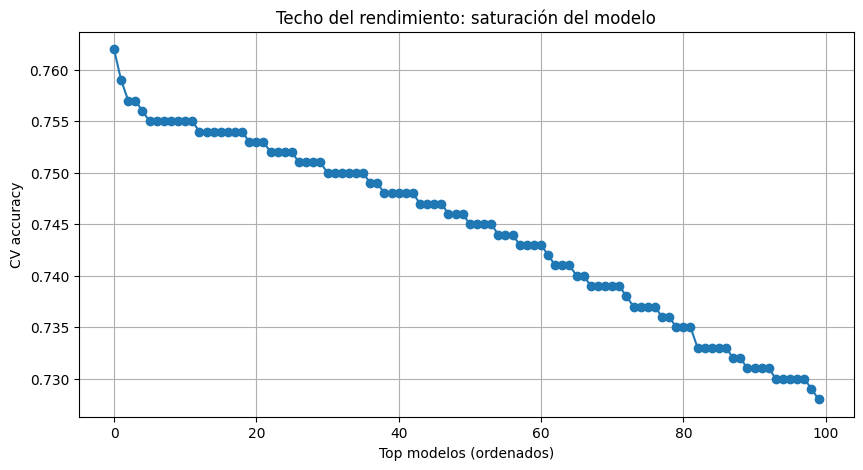

In [112]:
import pandas as pd

results = pd.DataFrame(grid.cv_results_)

top = results.sort_values("mean_test_score", ascending=False).head(100)

plt.figure(figsize=(10,5))
plt.plot(top["mean_test_score"].values, marker="o")
plt.xlabel("Top modelos (ordenados)")
plt.ylabel("CV accuracy")
plt.title("Techo del rendimiento: saturación del modelo")
plt.grid(True)
plt.show()

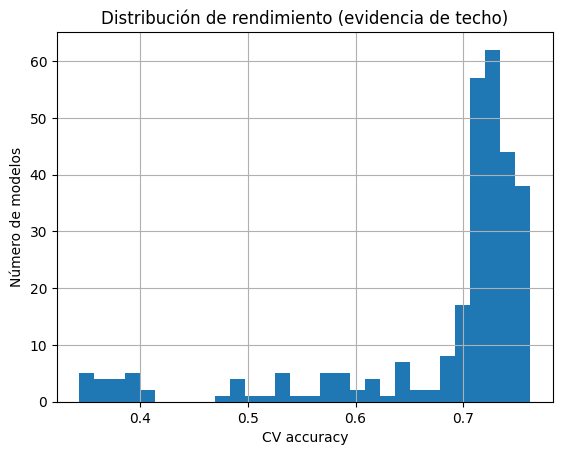

In [ ]:
plt.figure()
plt.hist(results["mean_test_score"], bins=30)
plt.xlabel("CV accuracy")
plt.ylabel("Número de modelos")
plt.title("Distribución de rendimiento (evidencia de techo)")
plt.grid(True)
plt.show()

Es decir, SelectKBest y shrinkage hacían trabajo solapado. Ambos combatían el mismo problema — la inestabilidad de Σ causada por demasiadas features ruidosas. Al eliminar el ruido con SelectKBest, el shrinkage ya no necesita ser tan agresivo y puede dejar más libertad al modelo para capturar la estructura discriminante real entre las clases.

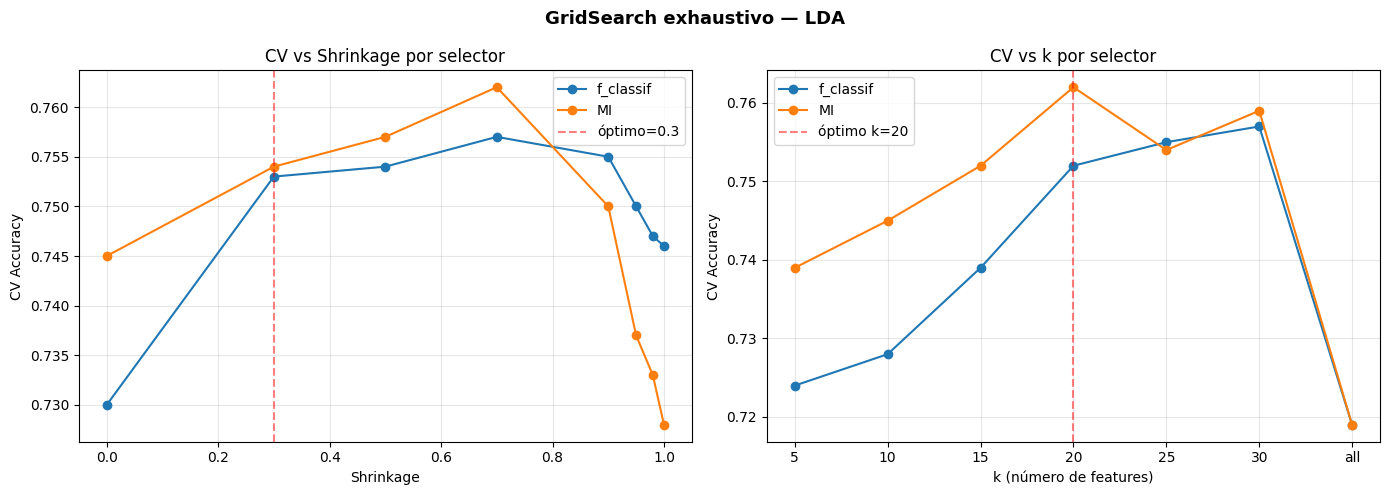

In [113]:
import matplotlib.pyplot as plt
import pandas as pd

# Extraer resultados del GridSearch
results_df = pd.DataFrame(grid.cv_results_)

# Filtrar solo rama SelectKBest (no PCA)
mask = results_df["param_reduce"].apply(lambda x: hasattr(x, 'score_func'))
skb_results = results_df[mask].copy()

# Extraer parámetros relevantes
skb_results["k"] = skb_results["param_reduce__k"].astype(str)
skb_results["shrinkage"] = skb_results["param_lda__shrinkage"]
skb_results["scaler"] = skb_results["param_scaler"].apply(lambda x: type(x).__name__)
skb_results["score_func"] = skb_results["param_reduce"].apply(
    lambda x: "f_classif" if "f_classif" in str(x.score_func) else "MI"
)

# ── Gráfica ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: CV por shrinkage coloreado por score_func
for func in ["f_classif", "MI"]:
    subset = skb_results[skb_results["score_func"] == func]
    grouped = subset.groupby("shrinkage")["mean_test_score"].max()
    axes[0].plot(grouped.index, grouped.values, marker="o", label=func)

axes[0].axvline(x=0.3, color="red", linestyle="--", alpha=0.5, label="óptimo=0.3")
axes[0].set_xlabel("Shrinkage")
axes[0].set_ylabel("CV Accuracy")
axes[0].set_title("CV vs Shrinkage por selector")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: CV por k coloreado por score_func
for func in ["f_classif", "MI"]:
    subset = skb_results[skb_results["score_func"] == func]
    k_order = [5, 10, 15, 20, 25, 30, "all"]
    grouped = subset.groupby("k")["mean_test_score"].max()
    grouped = grouped.reindex([str(k) for k in k_order])
    axes[1].plot(grouped.index, grouped.values, marker="o", label=func)

axes[1].axvline(x="20", color="red", linestyle="--", alpha=0.5, label="óptimo k=20")
axes[1].set_xlabel("k (número de features)")
axes[1].set_ylabel("CV Accuracy")
axes[1].set_title("CV vs k por selector")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("GridSearch exhaustivo — LDA", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# MODELO FINAL

In [114]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.feature_selection import SelectKBest, mutual_info_classif

lda_final = Pipeline([
    ("scaler",   PowerTransformer()),
    ("selector", SelectKBest(score_func=mutual_info_classif, k=20)),
    ("lda",      LinearDiscriminantAnalysis(solver="lsqr", shrinkage=0.3))
])

train, mean, std = evaluate(lda_final, X, y)
print(f"LDA final → Train: {train:.4f} | CV: {mean:.4f} ± {std:.4f}")

LDA final → Train: 0.7642 | CV: 0.7630 ± 0.0238


### PROBEMOS PORQUE QDA NO FUNCIONARIA

CONDICIÓN PARA USAR QDA

Para poder aplicar Quadratic Discriminant Analysis (QDA) es necesario que la matriz de covarianza de cada clase sea invertible, ya que el modelo requiere calcular Σ_c^{-1}. Esto solo es posible si el número de muestras por clase es mayor que el número de features: N_c > p.

En este caso, p = 609, pero cada clase tiene alrededor de 300 muestras, por lo que N_c < p. Esto implica que las matrices de covarianza son singulares (no invertibles) y QDA no puede aplicarse directamente.

Además, cada matriz de covarianza debe estimar p(p+1)/2 parámetros (≈185745 en este caso), lo que es demasiado para la cantidad de datos disponible y hace que las estimaciones sean poco fiables.

In [115]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

results_qda = []

for reg in [0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99]:
    qda = Pipeline([
        ("scaler", StandardScaler()),
        ("qda", QuadraticDiscriminantAnalysis(reg_param=reg))
    ])
    train_score, val_score, val_std = evaluate(qda, X, y)
    results_qda.append([f"QDA reg={reg}", train_score, val_score, val_std])

results_qda_df = pd.DataFrame(
    results_qda,
    columns=["Model", "Train Accuracy", "CV Accuracy", "Std"]
)
results_qda_df

c:\Users\laura\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
c:\Users\laura\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
c:\Users\laura\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 2 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
c:\Users\laura\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is 

,Model,Train Accuracy,CV Accuracy,Std
0,QDA reg=0.0,1.00000,0.326,0.015620
1,QDA reg=0.1,0.36975,0.394,0.039166
2,QDA reg=0.3,0.10225,0.407,0.041785
3,QDA reg=0.5,0.03775,0.402,0.043197
4,QDA reg=0.7,0.02675,0.406,0.027092
5,QDA reg=0.9,0.01575,0.417,0.022494
6,QDA reg=0.95,0.01125,0.430,0.021679
7,QDA reg=0.99,0.00400,0.424,0.020347


Para que QDA funcione necesitaríamos reducir p hasta que se cumpla Nc > p.
Con las muestras que tenemos, la condición más restrictiva es la clase C con 325 muestras, así que necesitaríamos p < 325, es decir, quedarnos con menos de 325 features.
Eso se puede conseguir con las mismas técnicas que ya usaste en el notebook:

SelectKBest con k < 325 — seleccionar las k features más discriminantes según f_classif o mutual_info y descartar el resto.
PCA con suficientes componentes descartados — proyectar a un espacio de dimensión < 325 donde Nc > p sí se cumpla.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.model_selection import cross_val_score

# Nc mínimo = 325 (clase C), necesitamos p < 325
# Probamos varios valores de n_components para ver cuál funciona mejor
results_qda_pca = []

for n in [50, 100, 150, 200, 250, 300, 320]:
    qda_pca = Pipeline([
        ("scaler",   PowerTransformer()),
        ("pca",      PCA(n_components=n)),
        ("qda",      QuadraticDiscriminantAnalysis())
    ])
    evaluate(qda_pca, X, y)
    results_qda_pca.append([
        f"PCA(n={n}) + QDA",
        round(train_score, 4),
        round(val_score, 4),
        round(val_std, 4)
    ])
    print(f"n={n} → Train: {train_score:.4f} | CV: {val_score:.4f} ± {val_std:.4f}")

pd.DataFrame(results_qda_pca, columns=["Model", "Train", "CV", "Std"])

n=50 → Train: 0.8690 | CV: 0.6520 ± 0.0238
n=100 → Train: 0.9860 | CV: 0.5770 ± 0.0344
n=150 → Train: 1.0000 | CV: 0.5100 ± 0.0493
n=200 → Train: 1.0000 | CV: 0.4580 ± 0.0340
n=250 → Train: 1.0000 | CV: 0.3910 ± 0.0235


c:\Users\laura\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
c:\Users\laura\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
c:\Users\laura\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 2 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
c:\Users\laura\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is 

n=300 → Train: 1.0000 | CV: 0.3740 ± 0.0235


c:\Users\laura\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
c:\Users\laura\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
c:\Users\laura\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 2 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
c:\Users\laura\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is 

n=320 → Train: 1.0000 | CV: 0.3320 ± 0.0229


c:\Users\laura\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 2 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(


,Model,Train,CV,Std
0,PCA(n=50) + QDA,0.869,0.652,0.0238
1,PCA(n=100) + QDA,0.986,0.577,0.0344
2,PCA(n=150) + QDA,1.000,0.510,0.0493
3,PCA(n=200) + QDA,1.000,0.458,0.0340
4,PCA(n=250) + QDA,1.000,0.391,0.0235
5,PCA(n=300) + QDA,1.000,0.374,0.0235
6,PCA(n=320) + QDA,1.000,0.332,0.0229


A medida que subes n, QDA tiene más dimensiones para memorizar el entrenamiento — Train sube hasta 1.0 perfecto — pero CV se desploma porque la estimación de Σc se vuelve cada vez más inestable al acercarse al límite Nc > p.

Podrimaos meter una pqeuña regulariacion adicional

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.model_selection import cross_val_score

results_qda_reg = []

for n in [30, 40, 50, 60, 70]:
    for reg in [0.0, 0.01, 0.05, 0.1, 0.2, 0.3, 0.5]:
        qda = Pipeline([
            ("scaler", PowerTransformer()),
            ("pca",    PCA(n_components=n)),
            ("qda",    QuadraticDiscriminantAnalysis(reg_param=reg))
        ])
        val_score, val_std, train_score = evaluate(qda, X, y)
        results_qda_reg.append([
            n, reg,
            round(train_score, 4),
            round(val_score, 4),
            round(val_std, 4)
        ])

df_qda = pd.DataFrame(results_qda_reg, columns=["n_components", "reg_param", "Train", "CV", "Std"])
df_qda.sort_values("CV", ascending=False).head(10)

,n_components,reg_param,Train,CV,Std
6,30,0.5,0.801,0.706,0.0107
27,60,0.5,0.923,0.702,0.0196
13,40,0.5,0.840,0.700,0.0167
20,50,0.5,0.888,0.678,0.0214
5,30,0.3,0.785,0.674,0.0124
34,70,0.5,0.944,0.669,0.0153
12,40,0.3,0.819,0.666,0.0224
26,60,0.3,0.915,0.666,0.0116
4,30,0.2,0.764,0.666,0.0124
24,60,0.1,0.906,0.665,0.0200


Mostrar más19:47Claude ha respondido: Interesante — el mejor QDA llega a CV=0.Interesante — el mejor QDA llega a CV=0.706 con n=30 y reg_param=0.5, que sigue sin superar al LDA final (CV=0.733). Además fíjate que reg_param=0.5 domina el top — necesita mucha regularización para no colapsar, lo que confirma que QDA sigue siendo inestable incluso después del PCA.